In [1]:
import os
import sys
import json
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import seaborn as sns
import sklearn.metrics
import tacco as tc
import time 
import tracemalloc 



In [ ]:
import os
from pathlib import Path

import anndata as ad


# 1. Configure local data directory

DATA_DIR = os.getenv("DATA_DIR")

if DATA_DIR is None:
    raise RuntimeError(
        "DATA_DIR is not set. "
        "Set DATA_DIR to the directory containing your "
        "Xenium AnnData files."
    )

DATA_DIR = Path(DATA_DIR)


# 2. Sample configuration


sample_config = {

    "sample_01": {
        "file": DATA_DIR / "sample_01" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_02": {
        "file": DATA_DIR / "sample_02" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_03": {
        "file": DATA_DIR / "sample_03" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_04": {
        "file": DATA_DIR / "sample_04" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_05": {
        "file": DATA_DIR / "sample_05" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_06": {
        "file": DATA_DIR / "sample_06" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_07": {
        "file": DATA_DIR / "sample_07" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_08": {
        "file": DATA_DIR / "sample_08" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_09": {
        "file": DATA_DIR / "sample_09" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_10": {
        "file": DATA_DIR / "sample_10" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_11": {
        "file": DATA_DIR / "sample_11" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_12": {
        "file": DATA_DIR / "sample_12" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_13": {
        "file": DATA_DIR / "sample_13" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_14": {
        "file": DATA_DIR / "sample_14" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_15": {
        "file": DATA_DIR / "sample_15" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Non-Cytopenic",
    },

    "sample_16": {
        "file": DATA_DIR / "sample_16" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },

    "sample_17": {
        "file": DATA_DIR / "sample_17" / "adspa_with_tacco_annotation.h5ad",
        "condition": "Cytopenic",
    },
}


# 3. Function to load an AnnData object

def load_sample(sample_id, config):

    file_path = config["file"]

    if not file_path.exists():
        raise FileNotFoundError(
            f"Input file for {sample_id} was not found:\n"
            f"{file_path}"
        )

    print(f"Loading {sample_id}")

    adata = ad.read_h5ad(file_path)

    return adata


# 4. Load all samples

adatas = []
sample_ids = []

for sample_id, config in sample_config.items():

    adata = load_sample(
        sample_id,
        config
    )

    adatas.append(adata)
    sample_ids.append(sample_id)


# 5. Concatenate samples

combined = ad.concat(
    adatas,
    axis=0,
    join="outer",
    label="sample",
    keys=sample_ids,
)


# 6. Add experimental condition

condition_map = {
    sample_id: config["condition"]
    for sample_id, config in sample_config.items()
}

combined.obs["condition"] = (
    combined.obs["sample"]
    .map(condition_map)
)


# 7. Check that every cell received a condition

if combined.obs["condition"].isna().any():

    missing_samples = (
        combined.obs.loc[
            combined.obs["condition"].isna(),
            "sample"
        ]
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Some samples do not have a condition assigned: "
        + ", ".join(missing_samples)
    )


# 8. Standardize Tacco cell-type annotation

if "Tacco_pred_cell_type" in combined.obs.columns:

    combined.obs["Tacco_pred_cell_type"] = (
        combined.obs["Tacco_pred_cell_type"]
        .replace(
            "Myeloma.mesenchymal",
            "Mesenchymal"
        )
    )

else:

    print(
        "Warning: 'Tacco_pred_cell_type' "
        "was not found in combined.obs."
    )



output_file = DATA_DIR / "combined_anndata.h5ad"

combined.write_h5ad(
    output_file
)


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/8y/pr3hwpm17132d6nyjkjsrys00000gq/T/ipykernel_29990/3984161367.py:54: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  combined.obs['Tacco_pred_cell_type'] = combined.obs['Tacco_pred_cell_type'].replace('Myeloma.mesenchymal', 'Mesenchymal')


In [3]:
# Analysis of cell type proportions at the sample level
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import pandas as pd

# First, create a dataframe with cell type counts per sample
sample_cell_counts = pd.crosstab(
    [combined.obs['condition'], combined.obs['sample']], 
    combined.obs['Tacco_pred_cell_type']
)
# Convert to percentages within each sample
sample_proportions = sample_cell_counts.div(sample_cell_counts.sum(axis=1), axis=0) * 100
print("\nCell type percentages by sample within each condition:")
print(sample_proportions.round(2).head())  # Show first few rows as example

# Reset index to make the dataframe easier to work with
sample_proportions_reset = sample_proportions.reset_index()


Cell type percentages by sample within each condition:
Tacco_pred_cell_type  B.cell  B.prog  Defensin+.neutrophil  Endothelial  \
condition sample                                                          
Cytopenic C2            0.62    6.69                  1.23         8.57   
          C4            0.44    7.10                  1.74         3.94   
          C3            2.31   13.87                  1.76         2.28   
          C1            0.46    5.73                  1.94         2.65   
          S_C5          2.21   12.13                  2.47         3.01   

Tacco_pred_cell_type  Erythrocyte  FCGR3B+.neutrophil   GMP   HSC  \
condition sample                                                    
Cytopenic C2                14.01                1.61  2.37  1.19   
          C4                23.98                2.36  2.65  1.30   
          C3                22.28                3.98  2.74  1.59   
          C1                29.91                3.06  3.27  0.99   
    

In [4]:
# Define cell_counts_by_sample variable using the existing sample_cell_counts
cell_counts_by_sample = sample_cell_counts.copy()



Hematopoietic Progenitors - Available cell types: ['HSC', 'MEP', 'GMP', 'MDP', 'NP']

Stromal/Structural Cells - Available cell types: ['Infl.mesenchymal', 'Mesenchymal', 'Osteolineage', 'SMC', 'Endothelial']

Mature Immune Cells - Available cell types: ['All_Neutrophils', 'Megakaryocyte', 'Monocyte', 'Mast.cell', 'Macrophage', 'Erythrocyte']


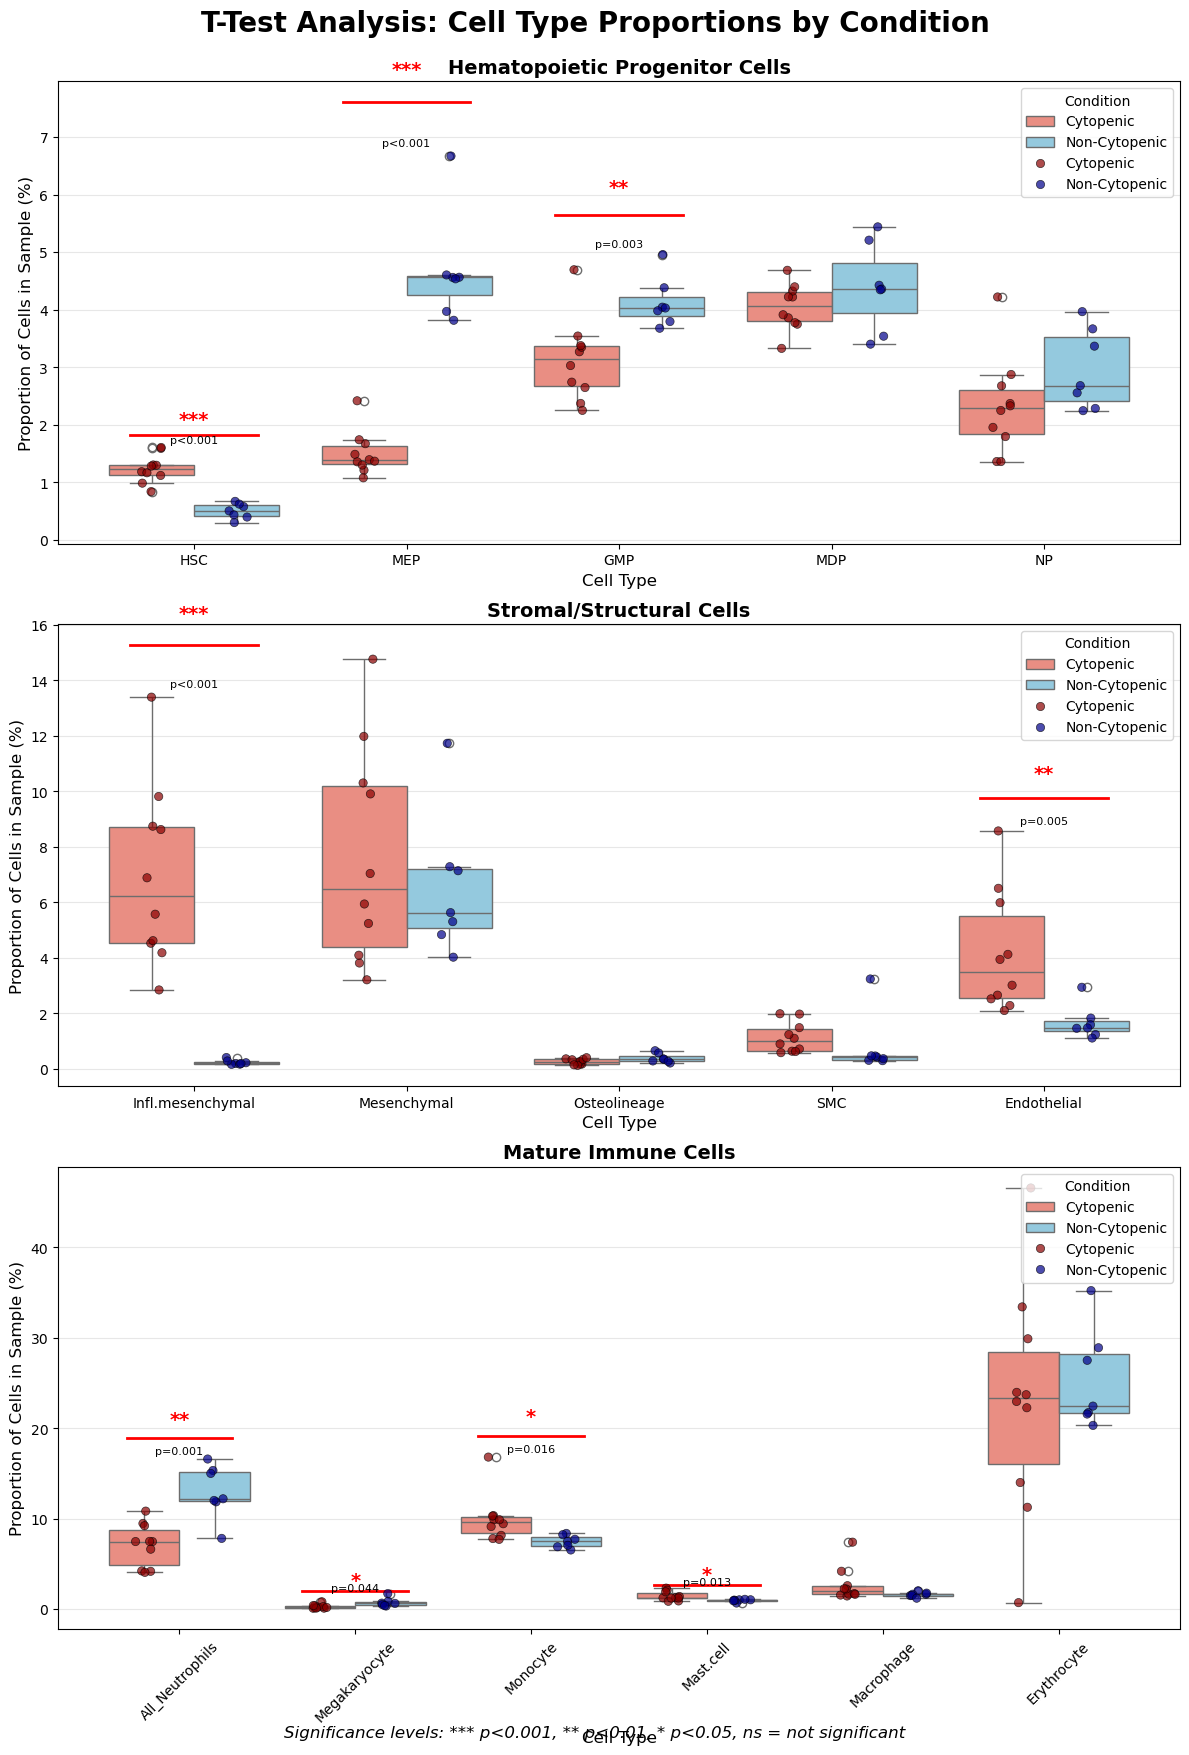

In [10]:
# T-TEST ANALYSIS - Box plots with asterisk significance indicators
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats

# Define significance levels with asterisks
def get_significance_asterisk(p_value):
    if pd.isna(p_value):
        return ''
    elif p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# Define the three groups of cell types
group1_progenitors = ['HSC', 'MEP', 'GMP', 'MDP', 'NP']
group2_stromal = ['Infl.mesenchymal', 'Mesenchymal', 'Osteolineage', 'SMC', 'Endothelial']
group3_mature_immune = [
    'All_Neutrophils',  # Combined neutrophil category
    'Megakaryocyte', 'Monocyte', 'Mast.cell', 'Macrophage', 'Erythrocyte'
]

# First, create combined neutrophil proportions if not already done
neutrophil_types = ['LTF+.neutrophil', 'MMP9+.neutrophil', 'Defensin+.neutrophil', 'FCGR3B+.neutrophil']
available_neutrophils = [nt for nt in neutrophil_types if nt in sample_proportions_reset.columns]

if available_neutrophils and 'All_Neutrophils' not in sample_proportions_reset.columns:
    print(f"Combining neutrophil subtypes: {available_neutrophils}")
    sample_proportions_reset['All_Neutrophils'] = sample_proportions_reset[available_neutrophils].sum(axis=1)
    print(f"Created 'All_Neutrophils' category with mean proportion: {sample_proportions_reset['All_Neutrophils'].mean():.2f}%")

# Function to create boxplot data and perform t-tests
def prepare_boxplot_data_ttest(cell_types, group_name):
    boxplot_data = []
    test_results = {}
    
    available_cell_types = [ct for ct in cell_types if ct in sample_proportions_reset.columns]
    
    if not available_cell_types:
        print(f"Warning: No cell types from {group_name} found in the data")
        return pd.DataFrame(), {}
    
    print(f"\n{group_name} - Available cell types: {available_cell_types}")
    
    for cell_type in available_cell_types:
        # Get data for each condition
        cytopenic_data = sample_proportions_reset[
            sample_proportions_reset['condition'] == 'Cytopenic'
        ][cell_type].values
        
        noncytopenic_data = sample_proportions_reset[
            sample_proportions_reset['condition'] == 'Non-Cytopenic'
        ][cell_type].values
        
        # Perform t-test
        if len(cytopenic_data) > 1 and len(noncytopenic_data) > 1:
            t_stat, p_value = stats.ttest_ind(cytopenic_data, noncytopenic_data, equal_var=False)
            test_results[cell_type] = {
                'p_value': p_value,
                'significance': get_significance_asterisk(p_value),
                'cytopenic_mean': np.mean(cytopenic_data),
                'noncytopenic_mean': np.mean(noncytopenic_data)
            }
        else:
            test_results[cell_type] = {
                'p_value': np.nan,
                'significance': 'ns',
                'cytopenic_mean': np.mean(cytopenic_data) if len(cytopenic_data) > 0 else 0,
                'noncytopenic_mean': np.mean(noncytopenic_data) if len(noncytopenic_data) > 0 else 0
            }
        
        # Prepare boxplot data
        for condition in ['Cytopenic', 'Non-Cytopenic']:
            condition_data = sample_proportions_reset[sample_proportions_reset['condition'] == condition]
            
            for _, row in condition_data.iterrows():
                boxplot_data.append({
                    'Cell Type': cell_type,
                    'Condition': condition,
                    'Sample': row['sample'],
                    'Proportion (%)': row[cell_type]
                })
    
    return pd.DataFrame(boxplot_data), test_results

# Function to add significance annotations with asterisks
def add_ttest_annotations(ax, boxplot_df, test_results, available_cell_types):
    for i, cell_type in enumerate(available_cell_types):
        if cell_type in test_results:
            significance = test_results[cell_type]['significance']
            p_value = test_results[cell_type]['p_value']
            
            # Get max y position for text placement
            max_y = boxplot_df[boxplot_df['Cell Type'] == cell_type]['Proportion (%)'].max()
            y_pos = max_y * 1.2
            
            # Add significance annotation - only show significant results
            if significance != 'ns':
                # Underline significant results
                ax.text(i, y_pos, significance, ha='center', va='bottom', 
                       fontsize=14, color='red', weight='bold')
                # Add underline for significant results
                ax.plot([i-0.3, i+0.3], [y_pos*0.95, y_pos*0.95], 
                       color='red', linewidth=2)
                
                # Add p-value below for significant results only
                if not pd.isna(p_value):
                    p_text = f"p={p_value:.3f}" if p_value >= 0.001 else f"p<0.001"
                    ax.text(i, y_pos*0.85, p_text, ha='center', va='bottom', 
                           fontsize=8, color='black')

# Create the three grouped box plots for T-TEST
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('T-Test Analysis: Cell Type Proportions by Condition', fontsize=20, fontweight='bold', y=0.98)

# Group 1: Hematopoietic Progenitors
boxplot_df1, test_results1 = prepare_boxplot_data_ttest(group1_progenitors, "Hematopoietic Progenitors")
if not boxplot_df1.empty:
    available_types1 = boxplot_df1['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df1, palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'}, ax=axes[0])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df1, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[0])
    
    add_ttest_annotations(axes[0], boxplot_df1, test_results1, available_types1)
    
    axes[0].set_title('Hematopoietic Progenitor Cells', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cell Type', fontsize=12)
    axes[0].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[0].legend(title='Condition', loc='upper right')
    axes[0].grid(axis='y', alpha=0.3)

# Group 2: Stromal/Structural Cells
boxplot_df2, test_results2 = prepare_boxplot_data_ttest(group2_stromal, "Stromal/Structural Cells")
if not boxplot_df2.empty:
    available_types2 = boxplot_df2['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df2, palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'}, ax=axes[1])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df2, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[1])
    
    add_ttest_annotations(axes[1], boxplot_df2, test_results2, available_types2)
    
    axes[1].set_title('Stromal/Structural Cells', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Cell Type', fontsize=12)
    axes[1].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[1].legend(title='Condition', loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)

# Group 3: Mature Immune Cells
boxplot_df3, test_results3 = prepare_boxplot_data_ttest(group3_mature_immune, "Mature Immune Cells")
if not boxplot_df3.empty:
    available_types3 = boxplot_df3['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df3, palette={'Cytopenic': 'salmon', 'Non-Cytopenic': 'skyblue'}, ax=axes[2])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df3, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[2])
    
    add_ttest_annotations(axes[2], boxplot_df3, test_results3, available_types3)
    
    axes[2].set_title('Mature Immune Cells', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Cell Type', fontsize=12)
    axes[2].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[2].legend(title='Condition', loc='upper right')
    axes[2].grid(axis='y', alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)

# Add significance legend
significance_text = "Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant"
fig.text(0.5, 0.02, significance_text, ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.08)
plt.show()




Hematopoietic Progenitors - Available cell types: ['HSC', 'MEP', 'GMP', 'MDP', 'NP']

Stromal/Structural Cells - Available cell types: ['Infl.mesenchymal', 'Mesenchymal', 'Osteolineage', 'SMC', 'Endothelial']

Mature Immune Cells - Available cell types: ['All_Neutrophils', 'Megakaryocyte', 'Monocyte', 'Mast.cell', 'Macrophage', 'Erythrocyte']


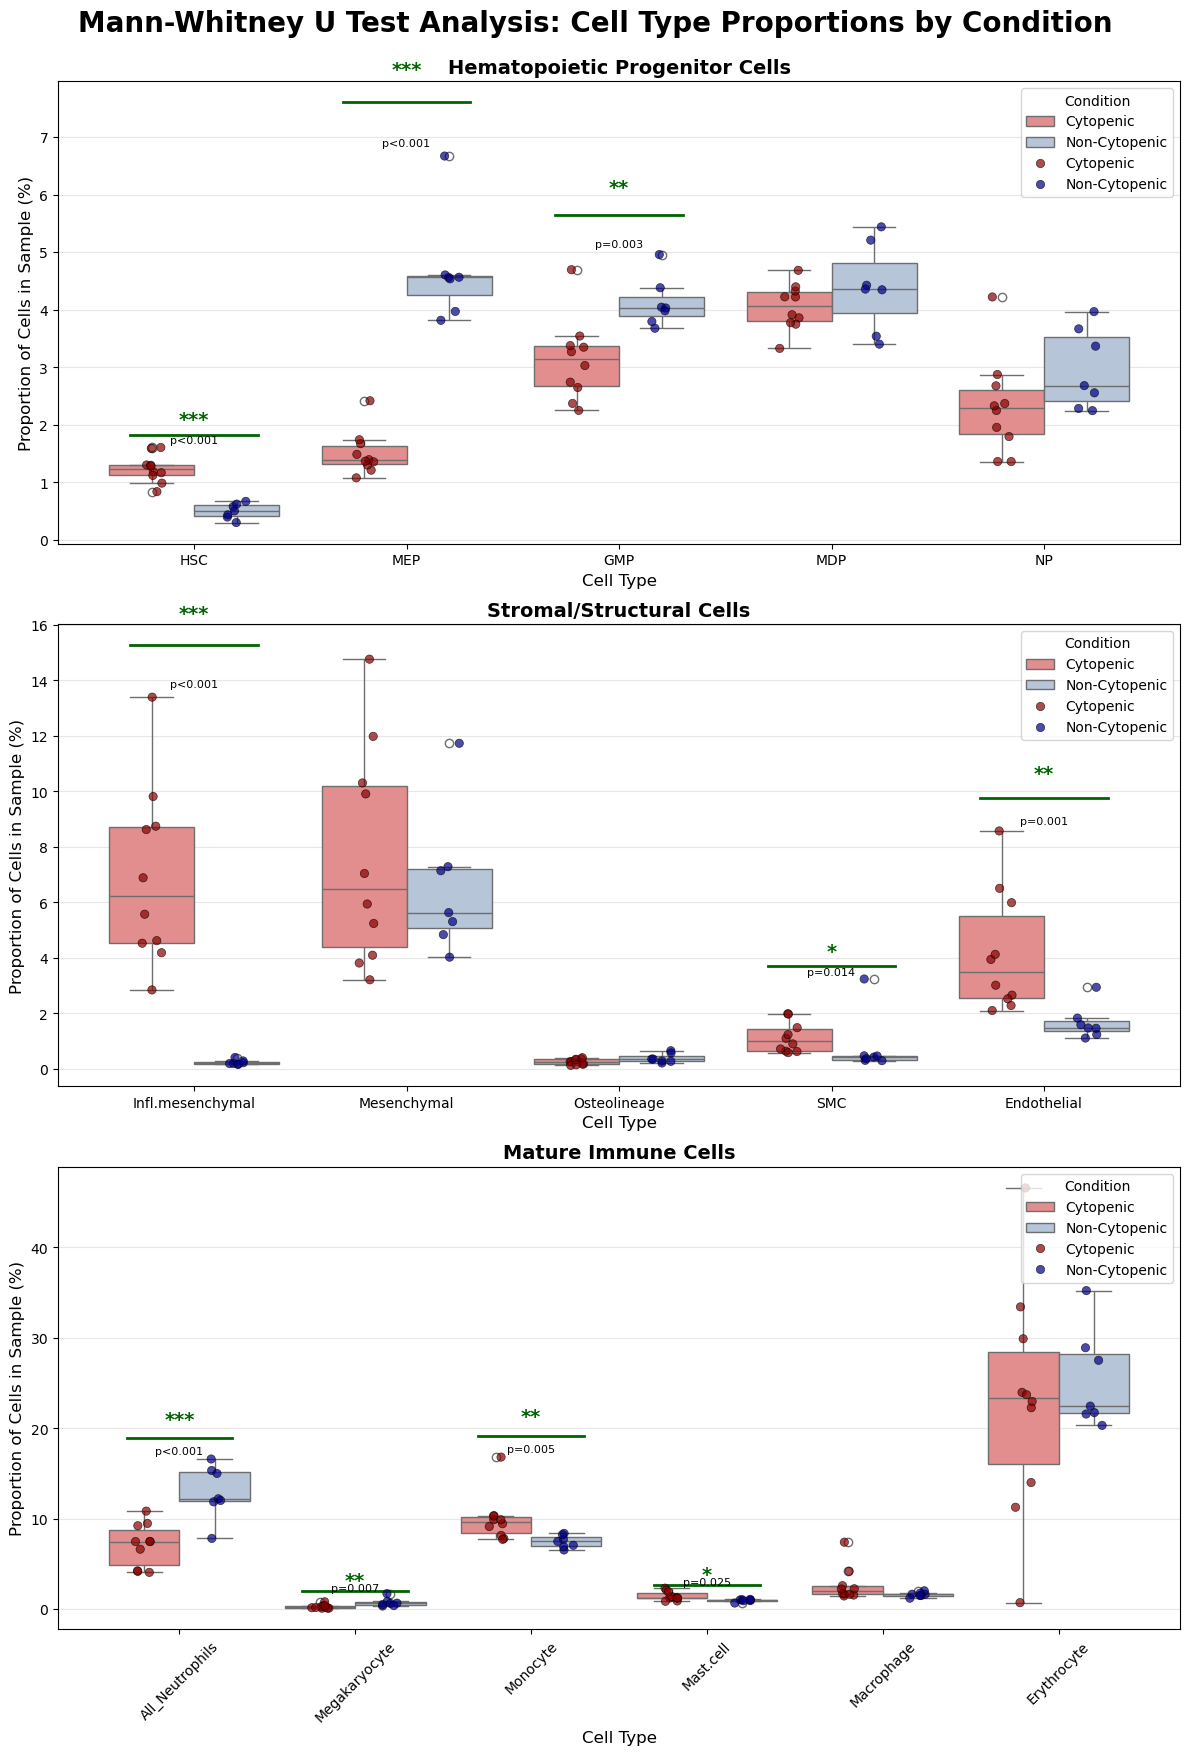

In [15]:
# MANN-WHITNEY TEST ANALYSIS - Box plots with asterisk significance indicators
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats

# Function to create boxplot data and perform Mann-Whitney tests
def prepare_boxplot_data_mannwhitney(cell_types, group_name):
    boxplot_data = []
    test_results = {}
    
    available_cell_types = [ct for ct in cell_types if ct in sample_proportions_reset.columns]
    
    if not available_cell_types:
        print(f"Warning: No cell types from {group_name} found in the data")
        return pd.DataFrame(), {}
    
    print(f"\n{group_name} - Available cell types: {available_cell_types}")
    
    for cell_type in available_cell_types:
        # Get data for each condition
        cytopenic_data = sample_proportions_reset[
            sample_proportions_reset['condition'] == 'Cytopenic'
        ][cell_type].values
        
        noncytopenic_data = sample_proportions_reset[
            sample_proportions_reset['condition'] == 'Non-Cytopenic'
        ][cell_type].values
        
        # Perform Mann-Whitney U test
        if len(cytopenic_data) > 0 and len(noncytopenic_data) > 0:
            try:
                u_stat, p_value = stats.mannwhitneyu(cytopenic_data, noncytopenic_data, alternative='two-sided')
                test_results[cell_type] = {
                    'p_value': p_value,
                    'significance': get_significance_asterisk(p_value),
                    'cytopenic_median': np.median(cytopenic_data),
                    'noncytopenic_median': np.median(noncytopenic_data),
                    'u_statistic': u_stat
                }
            except ValueError:
                test_results[cell_type] = {
                    'p_value': np.nan,
                    'significance': 'ns',
                    'cytopenic_median': np.median(cytopenic_data) if len(cytopenic_data) > 0 else 0,
                    'noncytopenic_median': np.median(noncytopenic_data) if len(noncytopenic_data) > 0 else 0,
                    'u_statistic': np.nan
                }
        else:
            test_results[cell_type] = {
                'p_value': np.nan,
                'significance': 'ns',
                'cytopenic_median': np.median(cytopenic_data) if len(cytopenic_data) > 0 else 0,
                'noncytopenic_median': np.median(noncytopenic_data) if len(noncytopenic_data) > 0 else 0,
                'u_statistic': np.nan
            }
        
        # Prepare boxplot data
        for condition in ['Cytopenic', 'Non-Cytopenic']:
            condition_data = sample_proportions_reset[sample_proportions_reset['condition'] == condition]
            
            for _, row in condition_data.iterrows():
                boxplot_data.append({
                    'Cell Type': cell_type,
                    'Condition': condition,
                    'Sample': row['sample'],
                    'Proportion (%)': row[cell_type]
                })
    
    return pd.DataFrame(boxplot_data), test_results

# Function to add significance annotations with asterisks for Mann-Whitney
def add_mannwhitney_annotations(ax, boxplot_df, test_results, available_cell_types):
    for i, cell_type in enumerate(available_cell_types):
        if cell_type in test_results:
            significance = test_results[cell_type]['significance']
            p_value = test_results[cell_type]['p_value']
            
            # Get max y position for text placement
            max_y = boxplot_df[boxplot_df['Cell Type'] == cell_type]['Proportion (%)'].max()
            y_pos = max_y * 1.2
            
            # Add significance annotation - only show significant results
            if significance != 'ns':
                # Underline significant results
                ax.text(i, y_pos, significance, ha='center', va='bottom', 
                       fontsize=14, color='darkgreen', weight='bold')
                # Add underline for significant results
                ax.plot([i-0.3, i+0.3], [y_pos*0.95, y_pos*0.95], 
                       color='darkgreen', linewidth=2)
                
                # Add p-value below for significant results only
                if not pd.isna(p_value):
                    p_text = f"p={p_value:.3f}" if p_value >= 0.001 else f"p<0.001"
                    ax.text(i, y_pos*0.85, p_text, ha='center', va='bottom', 
                           fontsize=8, color='black')

# Create the three grouped box plots for MANN-WHITNEY TEST
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Mann-Whitney U Test Analysis: Cell Type Proportions by Condition', fontsize=20, fontweight='bold', y=0.98)

# Group 1: Hematopoietic Progenitors
boxplot_df1_mw, test_results1_mw = prepare_boxplot_data_mannwhitney(group1_progenitors, "Hematopoietic Progenitors")
if not boxplot_df1_mw.empty:
    available_types1_mw = boxplot_df1_mw['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df1_mw, palette={'Cytopenic': 'lightcoral', 'Non-Cytopenic': 'lightsteelblue'}, ax=axes[0])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df1_mw, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[0])
    
    add_mannwhitney_annotations(axes[0], boxplot_df1_mw, test_results1_mw, available_types1_mw)
    
    axes[0].set_title('Hematopoietic Progenitor Cells', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cell Type', fontsize=12)
    axes[0].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[0].legend(title='Condition', loc='upper right')
    axes[0].grid(axis='y', alpha=0.3)

# Group 2: Stromal/Structural Cells
boxplot_df2_mw, test_results2_mw = prepare_boxplot_data_mannwhitney(group2_stromal, "Stromal/Structural Cells")
if not boxplot_df2_mw.empty:
    available_types2_mw = boxplot_df2_mw['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df2_mw, palette={'Cytopenic': 'lightcoral', 'Non-Cytopenic': 'lightsteelblue'}, ax=axes[1])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df2_mw, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[1])
    
    add_mannwhitney_annotations(axes[1], boxplot_df2_mw, test_results2_mw, available_types2_mw)
    
    axes[1].set_title('Stromal/Structural Cells', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Cell Type', fontsize=12)
    axes[1].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[1].legend(title='Condition', loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)

# Group 3: Mature Immune Cells
boxplot_df3_mw, test_results3_mw = prepare_boxplot_data_mannwhitney(group3_mature_immune, "Mature Immune Cells")
if not boxplot_df3_mw.empty:
    available_types3_mw = boxplot_df3_mw['Cell Type'].unique()
    sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                data=boxplot_df3_mw, palette={'Cytopenic': 'lightcoral', 'Non-Cytopenic': 'lightsteelblue'}, ax=axes[2])
    
    sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', dodge=True,
                 data=boxplot_df3_mw, palette={'Cytopenic': 'darkred', 'Non-Cytopenic': 'darkblue'},
                 size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[2])
    
    add_mannwhitney_annotations(axes[2], boxplot_df3_mw, test_results3_mw, available_types3_mw)
    
    axes[2].set_title('Mature Immune Cells', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Cell Type', fontsize=12)
    axes[2].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
    axes[2].legend(title='Condition', loc='upper right')
    axes[2].grid(axis='y', alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.subplots_adjust(top=0.94, bottom=0.08)
plt.show()



In [16]:
# EXPORT BOXPLOTS AS PDF with editable text and swapped condition order
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for editable text
matplotlib.rcParams['ps.fonttype'] = 42   # TrueType fonts for editable text

# Create a custom order for conditions (Non-Cytopenic on left, Cytopenic on right)
condition_order = ['Non-Cytopenic', 'Cytopenic']

# Custom palette with swapped order
custom_palette = {'Non-Cytopenic': 'skyblue', 'Cytopenic': 'salmon'}
custom_strip_palette = {'Non-Cytopenic': 'darkblue', 'Cytopenic': 'darkred'}

# Function to add significance annotations with editable text
def add_pdf_ttest_annotations(ax, boxplot_df, test_results, available_cell_types):
    for i, cell_type in enumerate(available_cell_types):
        if cell_type in test_results:
            significance = test_results[cell_type]['significance']
            p_value = test_results[cell_type]['p_value']
            
            # Get max y position for text placement
            max_y = boxplot_df[boxplot_df['Cell Type'] == cell_type]['Proportion (%)'].max()
            y_pos = max_y * 1.2
            
            # Add significance annotation - only show significant results
            if significance != 'ns':
                # Add asterisks with editable text
                ax.text(i, y_pos, significance, ha='center', va='bottom', 
                       fontsize=14, color='red', weight='bold')
                # Add underline for significant results
                ax.plot([i-0.3, i+0.3], [y_pos*0.95, y_pos*0.95], 
                       color='red', linewidth=2)
                
                # Add p-value below for significant results only
                if not pd.isna(p_value):
                    p_text = f"p={p_value:.3f}" if p_value >= 0.001 else f"p<0.001"
                    ax.text(i, y_pos*0.85, p_text, ha='center', va='bottom', 
                           fontsize=8, color='black')

def add_pdf_mannwhitney_annotations(ax, boxplot_df, test_results, available_cell_types):
    for i, cell_type in enumerate(available_cell_types):
        if cell_type in test_results:
            significance = test_results[cell_type]['significance']
            p_value = test_results[cell_type]['p_value']
            
            # Get max y position for text placement
            max_y = boxplot_df[boxplot_df['Cell Type'] == cell_type]['Proportion (%)'].max()
            y_pos = max_y * 1.2
            
            # Add significance annotation - only show significant results
            if significance != 'ns':
                # Add asterisks with editable text
                ax.text(i, y_pos, significance, ha='center', va='bottom', 
                       fontsize=14, color='darkgreen', weight='bold')
                # Add underline for significant results
                ax.plot([i-0.3, i+0.3], [y_pos*0.95, y_pos*0.95], 
                       color='darkgreen', linewidth=2)
                
                # Add p-value below for significant results only
                if not pd.isna(p_value):
                    p_text = f"p={p_value:.3f}" if p_value >= 0.001 else f"p<0.001"
                    ax.text(i, y_pos*0.85, p_text, ha='center', va='bottom', 
                           fontsize=8, color='black')

# Create PDF export for T-TEST analysis
def create_ttest_pdf():
    with PdfPages('/Users/cheung/Documents/10x_analysis/xenium/Tacco/ttest_boxplots.pdf') as pdf:
        fig, axes = plt.subplots(3, 1, figsize=(12, 18))
        fig.suptitle('T-Test Analysis: Cell Type Proportions by Condition', fontsize=20, fontweight='bold', y=0.98)
        
        # Group 1: Hematopoietic Progenitors
        boxplot_df1, test_results1 = prepare_boxplot_data_ttest(group1_progenitors, "Hematopoietic Progenitors")
        if not boxplot_df1.empty:
            available_types1 = boxplot_df1['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df1, palette=custom_palette, ax=axes[0])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df1, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[0])
            
            add_pdf_ttest_annotations(axes[0], boxplot_df1, test_results1, available_types1)
            
            axes[0].set_title('Hematopoietic Progenitor Cells', fontsize=14, fontweight='bold')
            axes[0].set_xlabel('Cell Type', fontsize=12)
            axes[0].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[0].legend(title='Condition', loc='upper right')
            axes[0].grid(axis='y', alpha=0.3)

        # Group 2: Stromal/Structural Cells
        boxplot_df2, test_results2 = prepare_boxplot_data_ttest(group2_stromal, "Stromal/Structural Cells")
        if not boxplot_df2.empty:
            available_types2 = boxplot_df2['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df2, palette=custom_palette, ax=axes[1])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df2, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[1])
            
            add_pdf_ttest_annotations(axes[1], boxplot_df2, test_results2, available_types2)
            
            axes[1].set_title('Stromal/Structural Cells', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Cell Type', fontsize=12)
            axes[1].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[1].legend(title='Condition', loc='upper right')
            axes[1].grid(axis='y', alpha=0.3)

        # Group 3: Mature Immune Cells
        boxplot_df3, test_results3 = prepare_boxplot_data_ttest(group3_mature_immune, "Mature Immune Cells")
        if not boxplot_df3.empty:
            available_types3 = boxplot_df3['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df3, palette=custom_palette, ax=axes[2])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df3, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[2])
            
            add_pdf_ttest_annotations(axes[2], boxplot_df3, test_results3, available_types3)
            
            axes[2].set_title('Mature Immune Cells', fontsize=14, fontweight='bold')
            axes[2].set_xlabel('Cell Type', fontsize=12)
            axes[2].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[2].legend(title='Condition', loc='upper right')
            axes[2].grid(axis='y', alpha=0.3)
            axes[2].tick_params(axis='x', rotation=45)

        # Add significance legend
        significance_text = "Significance levels: *** p<0.001, ** p<0.01, * p<0.05"
        fig.text(0.5, 0.02, significance_text, ha='center', fontsize=12, style='italic')

        plt.tight_layout()
        plt.subplots_adjust(top=0.94, bottom=0.08)
        
        
# Create PDF export for Mann-Whitney analysis
def create_mannwhitney_pdf():
    with PdfPages('/Users/cheung/Documents/10x_analysis/xenium/Tacco/mannwhitney_boxplots.pdf') as pdf:
        fig, axes = plt.subplots(3, 1, figsize=(12, 18))
        fig.suptitle('Mann-Whitney U Test Analysis: Cell Type Proportions by Condition', fontsize=20, fontweight='bold', y=0.98)
        
        # Group 1: Hematopoietic Progenitors
        boxplot_df1_mw, test_results1_mw = prepare_boxplot_data_mannwhitney(group1_progenitors, "Hematopoietic Progenitors")
        if not boxplot_df1_mw.empty:
            available_types1_mw = boxplot_df1_mw['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df1_mw, palette={'Non-Cytopenic': 'lightsteelblue', 'Cytopenic': 'lightcoral'}, ax=axes[0])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df1_mw, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[0])
            
            add_pdf_mannwhitney_annotations(axes[0], boxplot_df1_mw, test_results1_mw, available_types1_mw)
            
            axes[0].set_title('Hematopoietic Progenitor Cells', fontsize=14, fontweight='bold')
            axes[0].set_xlabel('Cell Type', fontsize=12)
            axes[0].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[0].legend(title='Condition', loc='upper right')
            axes[0].grid(axis='y', alpha=0.3)

        # Group 2: Stromal/Structural Cells
        boxplot_df2_mw, test_results2_mw = prepare_boxplot_data_mannwhitney(group2_stromal, "Stromal/Structural Cells")
        if not boxplot_df2_mw.empty:
            available_types2_mw = boxplot_df2_mw['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df2_mw, palette={'Non-Cytopenic': 'lightsteelblue', 'Cytopenic': 'lightcoral'}, ax=axes[1])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df2_mw, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[1])
            
            add_pdf_mannwhitney_annotations(axes[1], boxplot_df2_mw, test_results2_mw, available_types2_mw)
            
            axes[1].set_title('Stromal/Structural Cells', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Cell Type', fontsize=12)
            axes[1].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[1].legend(title='Condition', loc='upper right')
            axes[1].grid(axis='y', alpha=0.3)

        # Group 3: Mature Immune Cells
        boxplot_df3_mw, test_results3_mw = prepare_boxplot_data_mannwhitney(group3_mature_immune, "Mature Immune Cells")
        if not boxplot_df3_mw.empty:
            available_types3_mw = boxplot_df3_mw['Cell Type'].unique()
            sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order,
                        data=boxplot_df3_mw, palette={'Non-Cytopenic': 'lightsteelblue', 'Cytopenic': 'lightcoral'}, ax=axes[2])
            
            sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', hue_order=condition_order, dodge=True,
                         data=boxplot_df3_mw, palette=custom_strip_palette,
                         size=6, alpha=0.7, edgecolor='black', linewidth=0.5, ax=axes[2])
            
            add_pdf_mannwhitney_annotations(axes[2], boxplot_df3_mw, test_results3_mw, available_types3_mw)
            
            axes[2].set_title('Mature Immune Cells', fontsize=14, fontweight='bold')
            axes[2].set_xlabel('Cell Type', fontsize=12)
            axes[2].set_ylabel('Proportion of Cells in Sample (%)', fontsize=12)
            axes[2].legend(title='Condition', loc='upper right')
            axes[2].grid(axis='y', alpha=0.3)
            axes[2].tick_params(axis='x', rotation=45)

        # Add significance legend
        significance_text = "Significance levels: *** p<0.001, ** p<0.01, * p<0.05"
        fig.text(0.5, 0.02, significance_text, ha='center', fontsize=12, style='italic')

        plt.tight_layout()
        plt.subplots_adjust(top=0.94, bottom=0.08)
        
        # Save to PDF
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close()



Available lymphoid cell types: ['B.prog', 'B.cell', 'T.cell']

B.prog:
  Cytopenic samples: 10 - values: [ 6.68992586  7.10310328 13.87175917  5.73421155 12.12582351  9.58110739
  3.83498783  6.31047283  4.76167649  7.92719231]
  Non-Cytopenic samples: 7 - values: [6.17507313 5.61919639 3.30607892 4.41471224 4.72036037 5.82505405
 8.01269209]

B.cell:
  Cytopenic samples: 10 - values: [0.61927606 0.43744721 2.31417015 0.45718714 2.2102626  0.73393579
 0.35821315 0.70589667 0.44101433 0.60389555]
  Non-Cytopenic samples: 7 - values: [0.99085237 1.93525991 1.89447802 1.36918552 0.83715503 1.41375373
 2.5947304 ]

T.cell:
  Cytopenic samples: 10 - values: [ 4.7797645   5.23853867  3.85916053  4.52537776  6.17982741  7.2295172
  4.00824124 12.40187428  4.8703322  10.52989708]
  Non-Cytopenic samples: 7 - values: [3.67596084 2.73366311 2.20849627 5.78389775 2.7163442  3.09957004
 2.03809792]


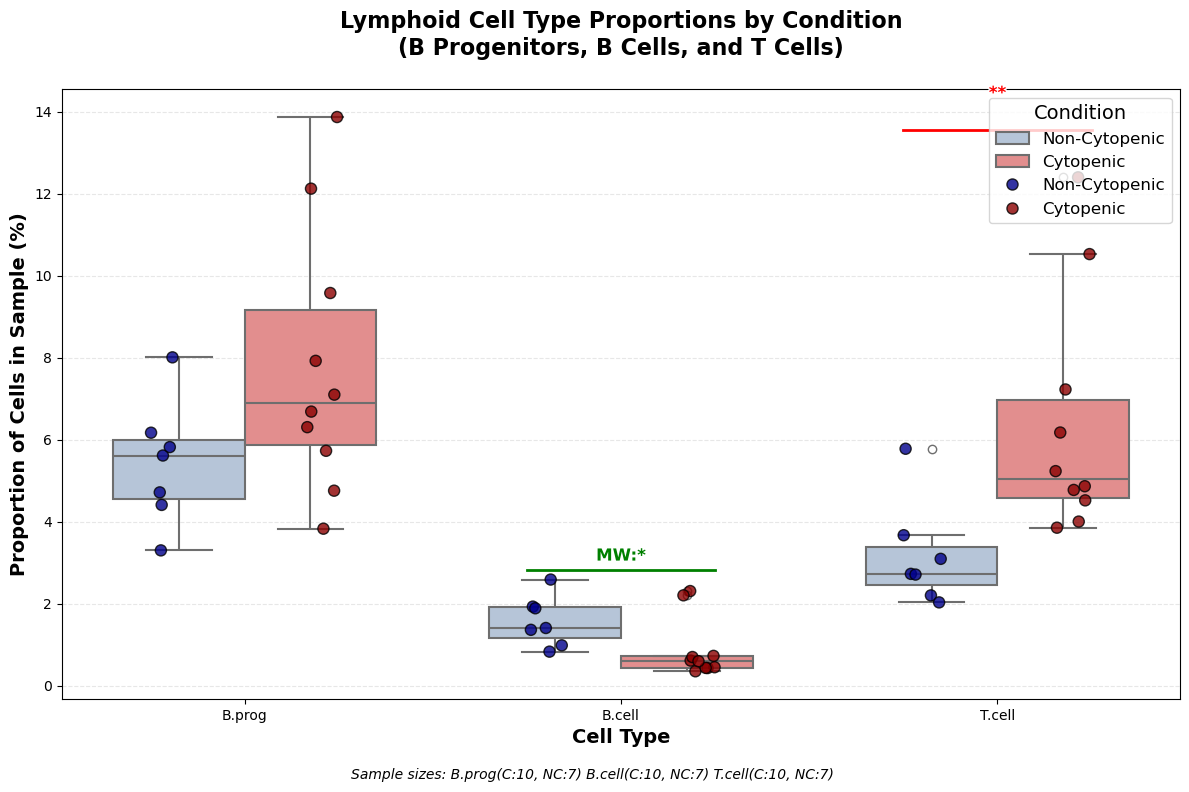

In [19]:
# BOX PLOTS FOR B.prog, B.cell, and T.cell WITH STATISTICAL TESTING
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.patheffects as pe

# Define the specific cell types of interest
lymphoid_cell_types = ['B.prog', 'B.cell', 'T.cell']

# Check which cell types are available in the data
available_lymphoid = [ct for ct in lymphoid_cell_types if ct in sample_proportions_reset.columns]
print(f"Available lymphoid cell types: {available_lymphoid}")

if not available_lymphoid:
    print("Warning: None of the specified lymphoid cell types found in the data")
    print(f"Available cell types in data: {list(sample_proportions_reset.columns)}")
else:
    # Function to prepare data and perform statistical tests for lymphoid cells
    def prepare_lymphoid_data_with_tests():
        boxplot_data = []
        test_results = {}
        
        for cell_type in available_lymphoid:
            # Get data for each condition
            cytopenic_data = sample_proportions_reset[
                sample_proportions_reset['condition'] == 'Cytopenic'
            ][cell_type].values
            
            noncytopenic_data = sample_proportions_reset[
                sample_proportions_reset['condition'] == 'Non-Cytopenic'
            ][cell_type].values
            
            print(f"\n{cell_type}:")
            print(f"  Cytopenic samples: {len(cytopenic_data)} - values: {cytopenic_data}")
            print(f"  Non-Cytopenic samples: {len(noncytopenic_data)} - values: {noncytopenic_data}")
            
            # Perform statistical tests
            results = {}
            
            # T-test
            if len(cytopenic_data) > 1 and len(noncytopenic_data) > 1:
                t_stat, t_p_value = stats.ttest_ind(cytopenic_data, noncytopenic_data, equal_var=False)
                results['t_test_p'] = t_p_value
                results['t_test_sig'] = get_significance_asterisk(t_p_value)
            else:
                results['t_test_p'] = np.nan
                results['t_test_sig'] = 'ns'
            
            # Mann-Whitney U test
            if len(cytopenic_data) > 0 and len(noncytopenic_data) > 0:
                try:
                    u_stat, mw_p_value = stats.mannwhitneyu(cytopenic_data, noncytopenic_data, alternative='two-sided')
                    results['mw_test_p'] = mw_p_value
                    results['mw_test_sig'] = get_significance_asterisk(mw_p_value)
                    results['u_statistic'] = u_stat
                except ValueError:
                    results['mw_test_p'] = np.nan
                    results['mw_test_sig'] = 'ns'
                    results['u_statistic'] = np.nan
            else:
                results['mw_test_p'] = np.nan
                results['mw_test_sig'] = 'ns'
                results['u_statistic'] = np.nan
            
            # Calculate descriptive statistics
            results['cytopenic_mean'] = np.mean(cytopenic_data) if len(cytopenic_data) > 0 else 0
            results['noncytopenic_mean'] = np.mean(noncytopenic_data) if len(noncytopenic_data) > 0 else 0
            results['cytopenic_median'] = np.median(cytopenic_data) if len(cytopenic_data) > 0 else 0
            results['noncytopenic_median'] = np.median(noncytopenic_data) if len(noncytopenic_data) > 0 else 0
            results['cytopenic_std'] = np.std(cytopenic_data, ddof=1) if len(cytopenic_data) > 1 else 0
            results['noncytopenic_std'] = np.std(noncytopenic_data, ddof=1) if len(noncytopenic_data) > 1 else 0
            
            test_results[cell_type] = results
            
            # Prepare boxplot data
            for condition in ['Cytopenic', 'Non-Cytopenic']:
                condition_data = sample_proportions_reset[sample_proportions_reset['condition'] == condition]
                
                for _, row in condition_data.iterrows():
                    boxplot_data.append({
                        'Cell Type': cell_type,
                        'Condition': condition,
                        'Sample': row['sample'],
                        'Proportion (%)': row[cell_type]
                    })
        
        return pd.DataFrame(boxplot_data), test_results

    # Prepare the data
    lymphoid_df, lymphoid_test_results = prepare_lymphoid_data_with_tests()
    
    if not lymphoid_df.empty:
        # Create the box plot
        plt.figure(figsize=(12, 8))
        
        # Custom order for conditions (Non-Cytopenic on left, Cytopenic on right)
        condition_order = ['Non-Cytopenic', 'Cytopenic']
        custom_palette = {'Non-Cytopenic': 'lightsteelblue', 'Cytopenic': 'lightcoral'}
        custom_strip_palette = {'Non-Cytopenic': 'darkblue', 'Cytopenic': 'darkred'}
        
        # Create box plot
        ax = sns.boxplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                        hue_order=condition_order, data=lymphoid_df, 
                        palette=custom_palette, width=0.7, linewidth=1.5)
        
        # Add individual sample points
        sns.stripplot(x='Cell Type', y='Proportion (%)', hue='Condition', 
                     hue_order=condition_order, dodge=True, data=lymphoid_df, 
                     palette=custom_strip_palette, size=8, alpha=0.8, 
                     edgecolor='black', linewidth=1, ax=ax)
        
        # Add significance annotations
        for i, cell_type in enumerate(available_lymphoid):
            if cell_type in lymphoid_test_results:
                results = lymphoid_test_results[cell_type]
                t_sig = results['t_test_sig']
                mw_sig = results['mw_test_sig']
                t_p = results['t_test_p']
                mw_p = results['mw_test_p']
                
                # Get max y position for text placement
                max_y = lymphoid_df[lymphoid_df['Cell Type'] == cell_type]['Proportion (%)'].max()
                y_pos = max_y * 1.15
                
                # Add significance annotations if either test is significant
                if t_sig != 'ns' or mw_sig != 'ns':
                    # Determine which test(s) to show
                    if t_sig != 'ns' and mw_sig != 'ns':
                        if t_sig == mw_sig:
                            # Both tests same significance
                            annotation_text = f"{t_sig}"
                            annotation_color = 'red'
                        else:
                            # Different significance levels
                            annotation_text = f"t:{t_sig}\nMW:{mw_sig}"
                            annotation_color = 'darkorange'
                    elif t_sig != 'ns':
                        annotation_text = f"t:{t_sig}"
                        annotation_color = 'blue'
                    elif mw_sig != 'ns':
                        annotation_text = f"MW:{mw_sig}"
                        annotation_color = 'green'
                    
                    # Add the annotation
                    ax.text(i, y_pos, annotation_text, ha='center', va='bottom', 
                           fontsize=12, fontweight='bold', color=annotation_color,
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])
                    
                    # Add connecting line for significance
                    ax.plot([i-0.25, i+0.25], [y_pos*0.95, y_pos*0.95], 
                           color=annotation_color, linewidth=2)
        
        # Formatting
        ax.set_title('Lymphoid Cell Type Proportions by Condition\n(B Progenitors, B Cells, and T Cells)', 
                    fontsize=16, fontweight='bold', pad=25)
        ax.set_ylabel('Proportion of Cells in Sample (%)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Cell Type', fontsize=14, fontweight='bold')
        ax.legend(title='Condition', fontsize=12, title_fontsize=14, loc='upper right')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add sample size information
        sample_counts = lymphoid_df.groupby(['Cell Type', 'Condition']).size().reset_index(name='Count')
        info_text = "Sample sizes: "
        for cell_type in available_lymphoid:
            cyto_count = sample_counts[(sample_counts['Cell Type'] == cell_type) & 
                                     (sample_counts['Condition'] == 'Cytopenic')]['Count'].values
            non_cyto_count = sample_counts[(sample_counts['Cell Type'] == cell_type) & 
                                         (sample_counts['Condition'] == 'Non-Cytopenic')]['Count'].values
            cyto_n = cyto_count[0] if len(cyto_count) > 0 else 0
            non_cyto_n = non_cyto_count[0] if len(non_cyto_count) > 0 else 0
            info_text += f"{cell_type}(C:{cyto_n}, NC:{non_cyto_n}) "
        
        plt.figtext(0.5, 0.02, info_text, ha='center', fontsize=10, style='italic')
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)
        plt.show()
        
       

Total cell types: 24
Cell types: B.cell, B.prog, Defensin+.neutrophil, Endothelial, Erythrocyte, FCGR3B+.neutrophil, GMP, HSC, Infl.mesenchymal, LTF+.Neutrophil, MDP, MEP, MMP9+.neutrophil, Macrophage, Mast.cell, Megakaryocyte, Mesenchymal, Monocyte, NP, Osteolineage, SMC, T.cell, cDC, pDC

Sample data shape: (17, 27)
Samples per condition:
Condition
Cytopenic        10
Non-Cytopenic     7
Name: count, dtype: int64


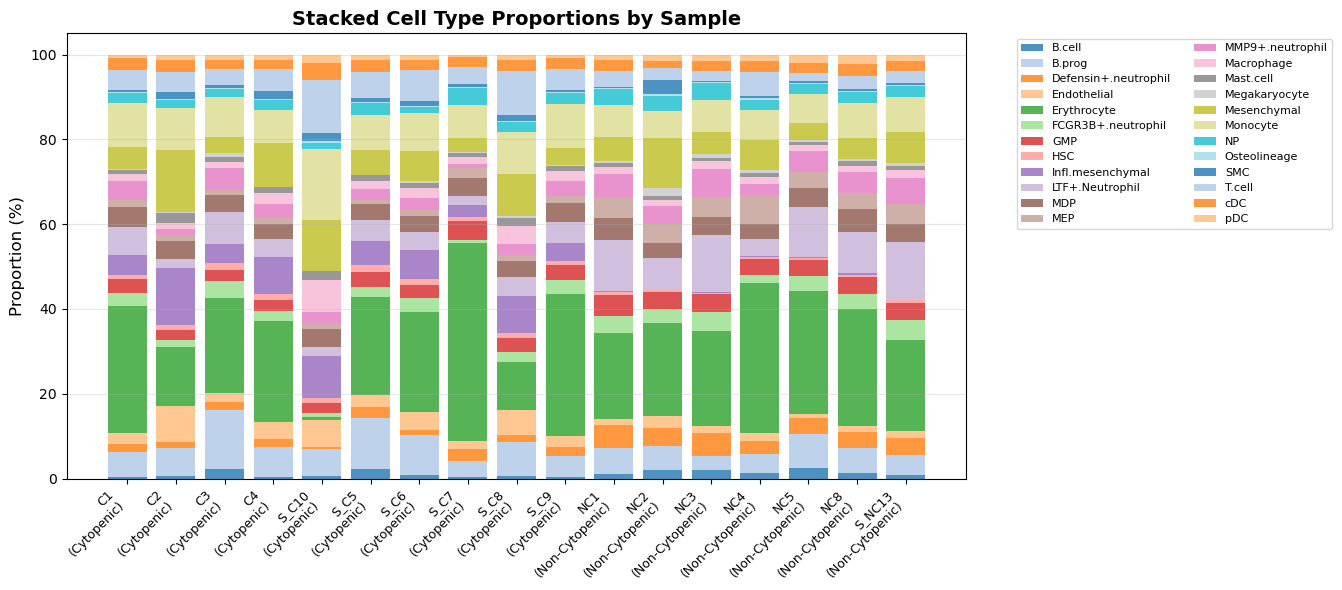

In [25]:
# CREATE CELL TYPE PROPORTION BAR CHART FOR EACH SAMPLE WITH SPECIFIED COLORS
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for editable text
matplotlib.rcParams['ps.fonttype'] = 42   # TrueType fonts for editable text

# Define color scheme as specified
all_cell_types = sorted(combined.obs['Tacco_pred_cell_type'].unique())
colors = sns.color_palette("tab20", n_colors=len(all_cell_types))
cell_type_colors = dict(zip(all_cell_types, colors))

print(f"Total cell types: {len(all_cell_types)}")
print(f"Cell types: {', '.join(all_cell_types)}")

# Calculate proportions for each sample
sample_proportions_individual = []
for sample_name in combined.obs['sample'].unique():
    sample_data = combined.obs[combined.obs['sample'] == sample_name]
    sample_condition = condition_map.get(sample_name, 'Unknown')
    
    # Calculate cell type proportions for this sample
    cell_type_counts = sample_data['Tacco_pred_cell_type'].value_counts()
    total_cells = len(sample_data)
    
    proportions = {}
    for cell_type in all_cell_types:
        proportion = (cell_type_counts.get(cell_type, 0) / total_cells) * 100
        proportions[cell_type] = proportion
    
    proportions['Sample'] = sample_name
    proportions['Condition'] = sample_condition
    proportions['Total_Cells'] = total_cells
    sample_proportions_individual.append(proportions)

# Convert to DataFrame
sample_props_df = pd.DataFrame(sample_proportions_individual)

# Sort samples by condition and then by name for better visualization
sample_props_df = sample_props_df.sort_values(['Condition', 'Sample'])

print(f"\nSample data shape: {sample_props_df.shape}")
print(f"Samples per condition:")
print(sample_props_df['Condition'].value_counts())

def create_sample_proportion_charts():
    """Stacked bar chart of cell type proportions per sample"""
    df = sample_props_df.reset_index(drop=True)
    n_samples = len(df)
    fig, ax = plt.subplots(figsize=(max(10, n_samples * 0.8), 6))

    sample_names = df['Sample'].tolist()
    x_pos = np.arange(n_samples)
    bottom = np.zeros(n_samples)

    for cell_type in all_cell_types:
        vals = df[cell_type].values
        ax.bar(x_pos, vals, bottom=bottom, label=cell_type,
               color=cell_type_colors[cell_type], alpha=0.8,
               edgecolor='none', linewidth=0)
        bottom += vals

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{n}\n({c})" for n, c in zip(sample_names, df['Condition'])],
                       fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('Proportion (%)', fontsize=12)
    ax.set_title('Stacked Cell Type Proportions by Sample', fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    ax.grid(axis='y', alpha=0.3)

    
    plt.tight_layout()
    return fig

fig = create_sample_proportion_charts()
plt.show()